# PINN-C for the Van de Vusse CSTR
### CHE 891 — Week 3

Implements PINN-C from Velioglu et al. (2025) using PyTorch.
The network takes $(t, \mathbf{x}^m(t_0), \mathbf{u})$ as inputs and outputs
all seven states $[c_A, c_B, T, T_K, k_1, k_2, k_3]$ simultaneously.
The rate constants $k_1, k_2, k_3$ are **unmeasured** — they are inferred
by enforcing the ODE residuals (Eqs. 3a–3d) via automatic differentiation.

**Reference:** M. Velioglu et al., Comp. Chem. Eng. 192, 108899 (2025). doi:10.1016/j.compchemeng.2024.108899

In [2]:
import builtins
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from matplotlib.pyplot import *

builtins_sum = builtins.sum   # preserve before pyplot can shadow it

torch.manual_seed(42)
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'PyTorch {torch.__version__} — device: {device}')

PyTorch 2.5.1+cu121 — device: cuda


## 1. Load Dataset

Generated in `week3_VdV_reactor.ipynb` using the full Arrhenius model.
We treat $k_1, k_2, k_3$ as ground truth for validation only — the PINN
does not see these during training.

In [3]:
data   = np.load('vdv_dataset.npz')
t_s    = data['t']        # (101,)       time in seconds
X      = data['X']        # (100, 101, 4) measured states [c_A, c_B, T, T_K]
U      = data['U']        # (100, 2)      inputs [D, Q_dot_K]
X0     = data['X0']       # (100, 4)      initial conditions
K_true = data['k_true']   # (100, 101, 3) ground-truth [k1, k2, k3]

N_traj, N_t, _ = X.shape
print(f'{N_traj} trajectories, {N_t} time steps each')

# Physical time in hours
t_h   = t_s / 3600        # (101,)
t_max = t_h[-1]           # 1/60 h

100 trajectories, 101 time steps each


## 2. Physical Parameters and Normalization

Inputs $(t, \mathbf{x}^m_0, \mathbf{u})$ and loss terms are normalized using
**mean-std (z-score)** standardization for consistency.
Network outputs are in physical units throughout.

In [4]:
# Physical constants (Table 2)
c_A_in = 5.10    # mol/L       feed concentration of A
T_in   = 378.1   # K           feed temperature
dH_AB  = 4.2     # kJ/mol      heat of reaction A→B
dH_BC  = -11.0   # kJ/mol      heat of reaction B→C
dH_AD  = -41.85  # kJ/mol      heat of reaction 2A→D
rho    = 0.9342  # kg/L        liquid density
Cp     = 3.01    # kJ/(kg·K)   heat capacity of reaction mixture
CpK    = 2.00    # kJ/(kg·K)   heat capacity of coolant
kw     = 4032.0  # kJ/(h·m²·K) wall heat transfer coefficient
AR     = 0.215   # m²          heat transfer area
VR     = 10.0    # L           reactor volume (0.01 m³)
mK     = 5.0     # kg          coolant mass

# Input normalisation — mean-std computed from the full dataset
x0_mean = torch.tensor(X0.mean(axis=0), dtype=torch.float32, device=device)
x0_std  = torch.tensor(X0.std(axis=0),  dtype=torch.float32, device=device)
u_mean  = torch.tensor(U.mean(axis=0),  dtype=torch.float32, device=device)
u_std   = torch.tensor(U.std(axis=0),   dtype=torch.float32, device=device)

def norm_x0(x):  return (x - x0_mean) / x0_std
def norm_u(u):   return (u - u_mean)  / u_std
def norm_t(t):   return t / t_max
def denorm_u(u): return u * u_std + u_mean

# Physics residual scales: typical ODE RHS magnitude in physical units
# dc/dt  ~ state_range × 60 h⁻¹  (60 = 1 / t_max in 1/h)
# dT/dt  ~ similar × 60
phys_scales = torch.tensor([30.0, 15.0, 960.0, 900.0], dtype=torch.float32, device=device)

# state_scales (for loss normalisation) computed below in data_prep from xm_tr.std()

# Output-layer bias for NN: start predictions near physical state means
# [c_A_mean, c_B_mean, T_mean, T_K_mean, k1_est, k2_est, k3_est]
out_bias_vals = torch.tensor(
    [2.35, 0.98, 395.0, 378.5, 10.0, 10.0, 2.0], dtype=torch.float32, device=device
)

print('x0_mean:', x0_mean.cpu().numpy().round(3))
print('x0_std: ', x0_std.cpu().numpy().round(3))
print(' u_mean:', u_mean.cpu().numpy().round(1))
print(' u_std: ', u_std.cpu().numpy().round(1))

x0_mean: [  2.355   0.98  395.003 378.496]
x0_std:  [0.124 0.063 4.619 4.336]
 u_mean: [   16.7 -1114.1]
 u_std:  [  6.8 642.8]


## 3. PINN Architecture

Feed-forward network with $\tanh$ activations following Velioglu et al.
Input dimension: $1 + 4 + 2 = 7$ (time + initial states + inputs).  
Output dimension: $7$ (four measured states + three rate constants).

In [5]:
model = nn.Sequential(
    nn.Linear(7, 64), nn.Tanh(),
    nn.Linear(64, 64), nn.Tanh(),
    nn.Linear(64, 7),
).to(device)

# Xavier initialisation for all linear layers
for m in model:
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        nn.init.zeros_(m.bias)

# Shift output-layer bias so initial predictions are near physical state means
# (otherwise T ≈ 0 at init instead of ≈ 395, inflating the loss)
model[-1].bias.data = out_bias_vals.to(device)

n_params = builtins_sum(p.numel() for p in model.parameters())
print(f'Parameters: {n_params}')
print(model)

Parameters: 5127
Sequential(
  (0): Linear(in_features=7, out_features=64, bias=True)
  (1): Tanh()
  (2): Linear(in_features=64, out_features=64, bias=True)
  (3): Tanh()
  (4): Linear(in_features=64, out_features=7, bias=True)
)


## 4. Physics Residuals

Given a batch of inputs $(t_\text{norm}, \mathbf{x}^m_0, \mathbf{u})$, compute the
ODE residuals of Eqs. 3a–3d.

The time derivative is obtained via automatic differentiation:
$$\frac{d\hat{x}}{dt} = \frac{d\hat{x}}{dt_\text{norm}} \cdot \frac{1}{t_\text{max}}$$

using `torch.autograd.grad` with `create_graph=True` so that
second-order gradients are available for L-BFGS.

In [6]:
def physics_residuals(model, t_norm, x0_norm, u_norm):
    """
    t_norm  : (N, 1) — normalised time, requires_grad must be True
    x0_norm : (N, 4) — normalised initial conditions
    u_norm  : (N, 2) — normalised inputs
    Returns four residual tensors (N, 1): res_a, res_b, res_c, res_d.
    """
    inp  = torch.cat([t_norm, x0_norm, u_norm], dim=1)  # (N, 7)
    out  = model(inp)                                    # (N, 7)

    c_A = out[:, 0:1];  c_B = out[:, 1:2]
    T   = out[:, 2:3];  T_K = out[:, 3:4]
    k1  = out[:, 4:5];  k2  = out[:, 5:6];  k3 = out[:, 6:7]

    # d/dt in physical units via AD
    def ddt(y):
        return torch.autograd.grad(
            y.sum(), t_norm, create_graph=True
        )[0] / t_max

    # Denormalise inputs to physical units
    u_phys  = denorm_u(u_norm)
    D       = u_phys[:, 0:1]   # 1/h
    Q_dot_K = u_phys[:, 1:2]   # kJ/h

    res_a = ddt(c_A) - (D*(c_A_in - c_A) - k1*c_A - k3*c_A**2)                    # Eq. 3a
    res_b = ddt(c_B) - (-D*c_B + k1*c_A - k2*c_B)                                  # Eq. 3b
    res_c = ddt(T)   - (D*(T_in - T)
                        - (k1*c_A*dH_AB + k2*c_B*dH_BC + k3*c_A**2*dH_AD)/(rho*Cp)
                        + kw*AR/(rho*Cp*VR)*(T_K - T))                              # Eq. 3c
    res_d = ddt(T_K) - (Q_dot_K + kw*AR*(T - T_K))/(mK*CpK)                        # Eq. 3d

    return res_a, res_b, res_c, res_d

## 5. Loss Function

$$\mathcal{L} = \mathcal{L}_\text{data} + \lambda_1\,\mathcal{L}_\text{physics} + \lambda_2\,\mathcal{L}_\text{init}$$

- $\mathcal{L}_\text{data}$: MSE on measured states $[c_A, c_B, T, T_K]$ at data points
- $\mathcal{L}_\text{physics}$: mean squared ODE residuals at the same points
- $\mathcal{L}_\text{init}$: MSE between predictions at $t=0$ and known initial conditions

Each term is normalised by its state or residual scale so that no single
output dominates the gradient.  We use fixed weights $\lambda_1 = \lambda_2 = 1$.

Velioglu uses **Inverse Dirichlet Weighting (IDW)** to adapt $\lambda_i$
during training based on gradient norms — covered separately.

In [7]:
def compute_loss(model, t_norm, x0_norm, u_norm, x_meas, x0_phys,
                 lam1=1.0, lam2=1.0):
    sc  = state_scales   # (4,) — for normalised state MSE
    psc = phys_scales    # (4,) — for normalised physics residuals
    N_traj = x0_phys.shape[0]
    N_t    = t_norm.shape[0] // N_traj

    # --- data loss (normalised by state scale so T doesn't dominate c_A) ---
    inp  = torch.cat([t_norm, x0_norm, u_norm], dim=1)
    pred = model(inp)
    L_data = ((pred[:, :4] - x_meas) / sc).pow(2).mean()

    # --- physics loss (need grad w.r.t. t) ---
    t_p = t_norm.detach().requires_grad_(True)
    res_a, res_b, res_c, res_d = physics_residuals(model, t_p, x0_norm, u_norm)
    L_phys = ((res_a / psc[0])**2 + (res_b / psc[1])**2 +
              (res_c / psc[2])**2 + (res_d / psc[3])**2).mean()

    # --- initial condition loss ---
    # One evaluation point per trajectory: stride N_t through the flattened arrays
    t_zero = torch.zeros(N_traj, 1, device=device)
    inp_ic = torch.cat([t_zero, x0_norm[::N_t], u_norm[::N_t]], dim=1)
    L_init = ((model(inp_ic)[:, :4] - x0_phys) / sc).pow(2).mean()

    loss = L_data + lam1 * L_phys + lam2 * L_init
    return loss, L_data.item(), L_phys.item(), L_init.item()

## 6. Prepare Training and Test Tensors

80 trajectories for training, 20 for testing (Velioglu high-data regime).
Each trajectory contributes 101 time points to the data and physics losses.

In [8]:
rng = np.random.default_rng(42)
idx = rng.permutation(N_traj)
train_idx, test_idx = idx[:80], idx[80:]

def make_tensors(traj_idx):
    """Flatten (N_traj, N_t, ...) arrays into (N_traj*N_t, ...) tensors."""
    N  = len(traj_idx)
    t_norm_np = np.tile(norm_t(t_h), N)                        # (N*Nt,)
    x0_np     = np.repeat(X0[traj_idx], N_t, axis=0)           # (N*Nt, 4)
    u_np      = np.repeat(U[traj_idx],  N_t, axis=0)           # (N*Nt, 2)
    x_meas_np = X[traj_idx].reshape(-1, 4)                     # (N*Nt, 4)

    t_t  = torch.tensor(t_norm_np, dtype=torch.float32).unsqueeze(1).to(device)
    x0_t = torch.tensor(x0_np,     dtype=torch.float32).to(device)
    u_t  = torch.tensor(u_np,      dtype=torch.float32).to(device)
    xm_t = torch.tensor(x_meas_np, dtype=torch.float32).to(device)

    x0_norm_t = norm_x0(x0_t)
    u_norm_t  = norm_u(u_t)
    x0_phys_t = torch.tensor(X0[traj_idx], dtype=torch.float32).to(device)

    return t_t, x0_norm_t, u_norm_t, xm_t, x0_phys_t

t_tr, x0n_tr, un_tr, xm_tr, x0p_tr = make_tensors(train_idx)
t_te, x0n_te, un_te, xm_te, x0p_te = make_tensors(test_idx)
print(f'Training samples: {t_tr.shape[0]}   Test samples: {t_te.shape[0]}')

# Loss normalisation: std of each measured state across training data
state_scales = xm_tr.std(dim=0)   # (4,) — [c_A_std, c_B_std, T_std, T_K_std]
print(f'\nstate_scales (training std): {state_scales.cpu().numpy().round(3)}')

Training samples: 8080   Test samples: 2020

state_scales (training std): [0.227 0.082 3.903 4.113]


## 7. Training

Following Velioglu: Adam for 1000 epochs to reach a good basin,
then L-BFGS for fine-tuning.

In [9]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

n_epochs  = 1000
loss_hist = []

for epoch in range(n_epochs):
    optimizer.zero_grad()
    loss, Ld, Lp, Li = compute_loss(
        model, t_tr, x0n_tr, un_tr, xm_tr, x0p_tr)
    loss.backward()
    optimizer.step()
    loss_hist.append(loss.item())
    if (epoch + 1) % 100 == 0:
        print(f'Epoch {epoch+1:4d}  loss={loss.item():.4e}  '
              f'data={Ld:.4e}  phys={Lp:.4e}  init={Li:.4e}')

Epoch  100  loss=3.0488e+00  data=9.3327e-01  phys=1.4857e+00  init=6.2983e-01
Epoch  200  loss=1.1460e+00  data=3.4935e-01  phys=2.5739e-01  init=5.3922e-01
Epoch  300  loss=6.7020e-01  data=1.8987e-01  phys=1.8652e-01  init=2.9381e-01
Epoch  400  loss=4.3535e-01  data=1.1958e-01  phys=1.5169e-01  init=1.6408e-01
Epoch  500  loss=3.2731e-01  data=8.7953e-02  phys=1.2681e-01  init=1.1254e-01
Epoch  600  loss=2.5331e-01  data=6.6984e-02  phys=1.0236e-01  init=8.3970e-02
Epoch  700  loss=1.9578e-01  data=5.2845e-02  phys=8.0003e-02  init=6.2935e-02
Epoch  800  loss=1.5008e-01  data=4.2365e-02  phys=6.1330e-02  init=4.6388e-02
Epoch  900  loss=1.1622e-01  data=3.4259e-02  phys=4.7899e-02  init=3.4058e-02
Epoch 1000  loss=9.2199e-02  data=2.8140e-02  phys=3.8509e-02  init=2.5550e-02


In [10]:
optimizer_lb = torch.optim.LBFGS(
    model.parameters(), lr=0.1, max_iter=20,
    history_size=50, line_search_fn='strong_wolfe'
)

lbfgs_hist = []

for epoch in range(300):
    def closure():
        optimizer_lb.zero_grad()
        loss, *_ = compute_loss(
            model, t_tr, x0n_tr, un_tr, xm_tr, x0p_tr)
        loss.backward()
        return loss
    loss_val = optimizer_lb.step(closure)
    lbfgs_hist.append(loss_val.item())
    if (epoch + 1) % 50 == 0:
        print(f'L-BFGS epoch {epoch+1:3d}  loss={loss_val.item():.4e}')

L-BFGS epoch  50  loss=3.1915e-03
L-BFGS epoch 100  loss=1.0781e-03
L-BFGS epoch 150  loss=4.3725e-04
L-BFGS epoch 200  loss=2.9644e-04
L-BFGS epoch 250  loss=2.3143e-04
L-BFGS epoch 300  loss=1.9525e-04


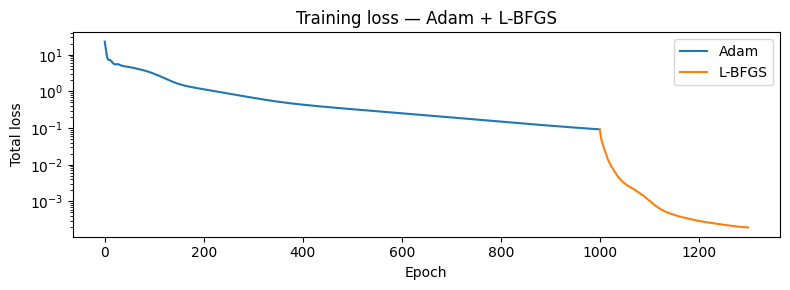

In [11]:
figure(figsize=(8, 3))
semilogy(loss_hist, label='Adam')
semilogy(range(n_epochs, n_epochs + len(lbfgs_hist)), lbfgs_hist, label='L-BFGS')
xlabel('Epoch');  ylabel('Total loss');  legend()
title('Training loss — Adam + L-BFGS')
tight_layout();  show()

## 8. Evaluation — Measured States

Compare the PINN predictions of $c_A, c_B, T, T_K$ on the test set
against the ground-truth trajectories.

In [12]:
from sklearn.metrics import r2_score

model.eval()
with torch.no_grad():
    inp_te  = torch.cat([t_te, x0n_te, un_te], dim=1)
    pred_te = model(inp_te).cpu().numpy()   # (N_test*N_t, 7)

# Pull the test data into numpy on the CPU
xm_te_np = xm_te.cpu().numpy()             # (N_test*N_t, 4)

state_labels = ['$c_A$', '$c_B$', '$T$', '$T_K$']
for j, label in enumerate(state_labels):
    r2 = r2_score(xm_te_np[:, j], pred_te[:, j])
    print(f'  {label:6s}  R² = {r2:.4f}')

  $c_A$   R² = 0.9960
  $c_B$   R² = 0.9912
  $T$     R² = 0.9990
  $T_K$   R² = 0.9994


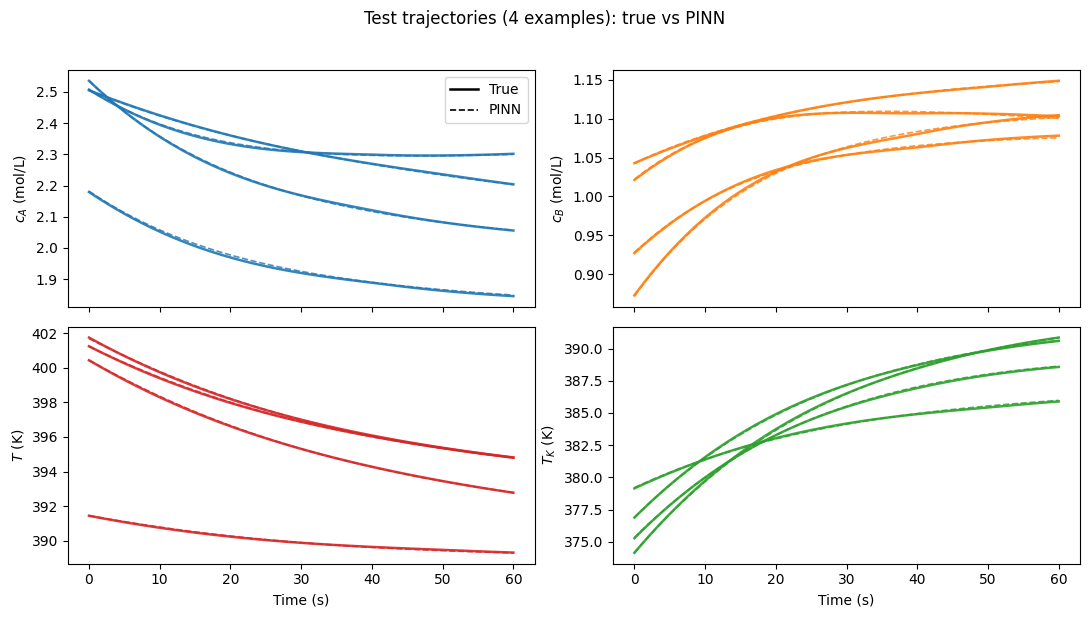

In [13]:
# Plot a few test trajectories: PINN prediction vs ground truth
N_te = len(test_idx)
n_plot = min(4, N_te)
plot_ids = np.arange(n_plot)

pred_te_states = pred_te[:, :4].reshape(N_te, N_t, 4)
true_te_states = xm_te_np.reshape(N_te, N_t, 4)

state_labels = [r'$c_A$ (mol/L)', r'$c_B$ (mol/L)', r'$T$ (K)', r'$T_K$ (K)']
colors = ['tab:blue', 'tab:orange', 'tab:red', 'tab:green']

fig, axes = subplots(2, 2, figsize=(11, 6), sharex=True)
for ax, j, label, color in zip(axes.flat, range(4), state_labels, colors):
    for i in plot_ids:
        ax.plot(t_s, true_te_states[i, :, j], color=color, lw=1.8, alpha=0.9)
        ax.plot(t_s, pred_te_states[i, :, j], '--', color=color, lw=1.2, alpha=0.8)
    ax.set_ylabel(label)

axes[1, 0].set_xlabel('Time (s)')
axes[1, 1].set_xlabel('Time (s)')
axes[0, 0].plot([], [], 'k-',  lw=1.8, label='True')
axes[0, 0].plot([], [], 'k--', lw=1.2, label='PINN')
axes[0, 0].legend(loc='best')

suptitle(f'Test trajectories ({n_plot} examples): true vs PINN', y=1.02)
tight_layout()
show()

## 9. Evaluation — Inferred Rate Constants

Compare the PINN-inferred $k_1, k_2, k_3$ against the ground truth computed
from $T(t)$ via the Arrhenius equation — the target the PINN was never shown.

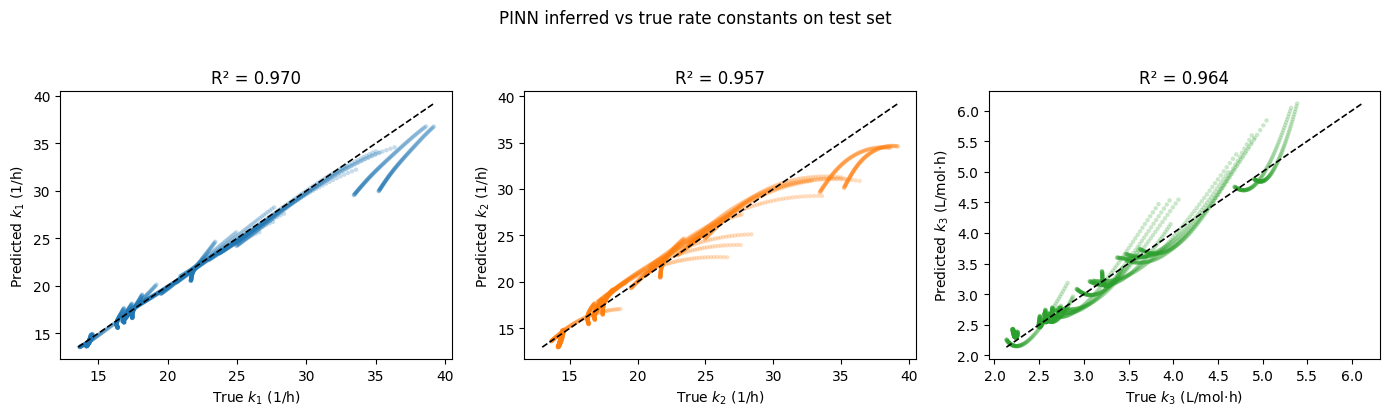

In [14]:
N_te = len(test_idx)
K_true_te = K_true[test_idx].reshape(N_te * N_t, 3)  # ground truth
K_pred_te = pred_te[:, 4:]                            # PINN output

k_labels = [r'$k_1$ (1/h)', r'$k_2$ (1/h)', r'$k_3$ (L/mol·h)']
colors = ['tab:blue', 'tab:orange', 'tab:green']

fig, axes = subplots(1, 3, figsize=(14, 4))
for j, (ax, label, color) in enumerate(zip(axes, k_labels, colors)):
    ax.scatter(K_true_te[:, j], K_pred_te[:, j], s=10, alpha=0.25, color=color, edgecolors='none')
    lo = min(K_true_te[:, j].min(), K_pred_te[:, j].min())
    hi = max(K_true_te[:, j].max(), K_pred_te[:, j].max())
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1.2)
    r2 = r2_score(K_true_te[:, j], K_pred_te[:, j])
    ax.set_xlabel(f'True {label}')
    ax.set_ylabel(f'Predicted {label}')
    ax.set_title(f'R² = {r2:.3f}')

suptitle('PINN inferred vs true rate constants on test set', y=1.03)
tight_layout()
show()

## 10. Arrhenius Plot

If the PINN has correctly inferred $k_1$ and $k_3$, plotting $\ln k_i$ vs $1/T$
should recover the linear Arrhenius relationship — even though the network
was never told this functional form.

In [15]:
# T from test trajectories
T_te = X[test_idx, :, 2].reshape(-1)   # (N_te*N_t,)
inv_T_te = 1 / T_te

# Arrhenius parameters (Table 2)
k10 = 1.287e12;  Ea1 = -9758.3
k30 = 9.043e9;   Ea3 = -8560.0

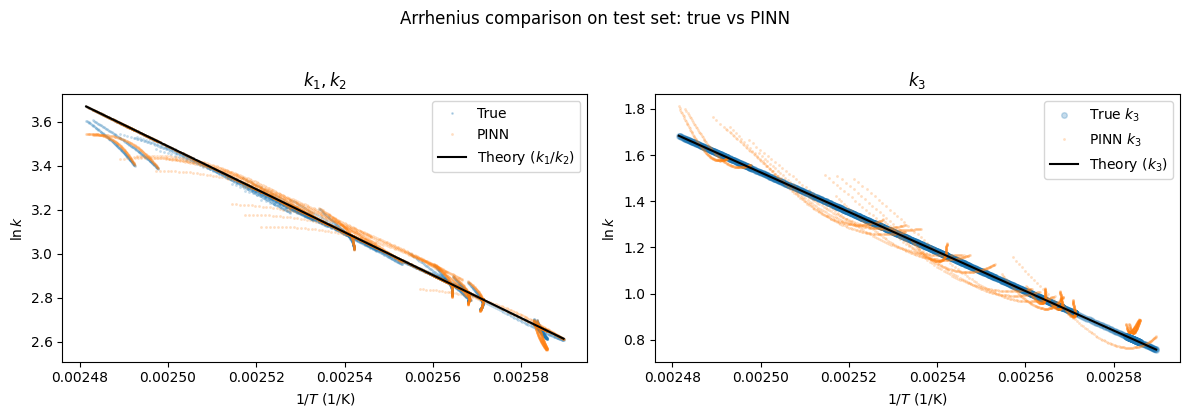

In [16]:
# Arrhenius comparison: ln(k) vs 1/T on the test set
eps = 1e-12

fig, axes = subplots(1, 2, figsize=(12, 4), sharex=True)

# k1/k2 comparison (they share the same Arrhenius parameters in this model)
ax = axes[0]
for idx, name, color in [(0, r'$k_1$', 'tab:blue'), (1, r'$k_2$', 'tab:orange')]:
    k_true_j = K_true_te[:, idx]
    k_pred_j = K_pred_te[:, idx]
    m_true = k_true_j > eps
    m_pred = k_pred_j > eps
    ax.plot(inv_T_te[m_true], np.log(k_true_j[m_true]), '.', ms=2, alpha=0.25, color=color,label='True'if idx == 0 else None)
    ax.plot(inv_T_te[m_pred], np.log(k_pred_j[m_pred]), '.', ms=2, alpha=0.25, color=color, markerfacecolor='none',label='PINN'if idx == 1 else None)

T_line = np.linspace(T_te.min(), T_te.max(), 200)
ax.plot(1 / T_line, np.log(k10 * np.exp(Ea1 / T_line)), 'k-', lw=1.5, label='Theory ($k_1$/$k_2$)')
ax.set_xlabel(r'$1/T$ (1/K)')
ax.set_ylabel(r'$\ln k$')
ax.set_title(r'$k_1, k_2$')
ax.legend(loc='best')

# k3 comparison
ax = axes[1]
k_true_3 = K_true_te[:, 2]
k_pred_3 = K_pred_te[:, 2]
m_true_3 = k_true_3 > eps
m_pred_3 = k_pred_3 > eps
ax.plot(inv_T_te[m_true_3], np.log(k_true_3[m_true_3]), '.', ms=8, alpha=0.25, color='tab:blue', label='True $k_3$')
ax.plot(inv_T_te[m_pred_3], np.log(k_pred_3[m_pred_3]), '.', ms=2, alpha=0.25, color='tab:orange', markerfacecolor='none', label='PINN $k_3$')
ax.plot(1 / T_line, np.log(k30 * np.exp(Ea3 / T_line)), 'k-', lw=1.5, label='Theory ($k_3$)')
ax.set_xlabel(r'$1/T$ (1/K)')
ax.set_ylabel(r'$\ln k$')
ax.set_title(r'$k_3$')
ax.legend(loc='best')

suptitle('Arrhenius comparison on test set: true vs PINN', y=1.03)
tight_layout()
show()

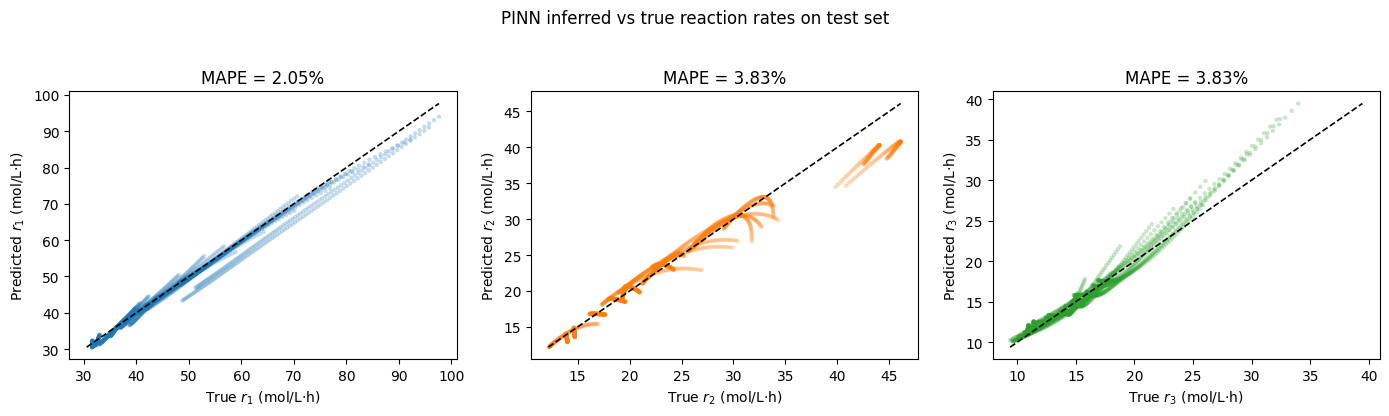

In [19]:
# Compare reaction rates (r1, r2, r3) instead of rate constants

N_te = len(test_idx)

# True states/rates on test set
X_te = X[test_idx].reshape(N_te * N_t, 4)
cA_true = X_te[:, 0]
cB_true = X_te[:, 1]
r_true = np.column_stack([
    K_true_te[:, 0] * cA_true,        # r1 = k1 * cA
    K_true_te[:, 1] * cB_true,        # r2 = k2 * cB
    K_true_te[:, 2] * cA_true**2,     # r3 = k3 * cA^2
])

# PINN-predicted states/rates on test set
cA_pred = pred_te[:, 0]
cB_pred = pred_te[:, 1]
r_pred = np.column_stack([
    K_pred_te[:, 0] * cA_pred,        # r1_hat
    K_pred_te[:, 1] * cB_pred,        # r2_hat
    K_pred_te[:, 2] * cA_pred**2,     # r3_hat
])

rate_labels = [r'$r_1$ (mol/L·h)', r'$r_2$ (mol/L·h)', r'$r_3$ (mol/L·h)']
colors = ['tab:blue', 'tab:orange', 'tab:green']

eps = 1e-8  # avoid divide-by-zero in MAPE
fig, axes = subplots(1, 3, figsize=(14, 4))
for j, (ax, label, color) in enumerate(zip(axes, rate_labels, colors)):
    ax.scatter(r_true[:, j], r_pred[:, j], s=10, alpha=0.25, color=color, edgecolors='none')
    lo = min(r_true[:, j].min(), r_pred[:, j].min())
    hi = max(r_true[:, j].max(), r_pred[:, j].max())
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1.2)
    mape = np.mean(np.abs((r_true[:, j] - r_pred[:, j]) / np.maximum(np.abs(r_true[:, j]), eps))) * 100
    ax.set_xlabel(f'True {label}')
    ax.set_ylabel(f'Predicted {label}')
    ax.set_title(f'MAPE = {mape:.2f}%')

suptitle('PINN inferred vs true reaction rates on test set', y=1.03)
tight_layout()
show()

Compared to velioglu, i am getting somewhat better values. I am not sure why my results here look better than Velioglu, but it may be because I am running less model variety then they did.

In [22]:
# GradNorm loss balancing 
import torch
import torch.nn as nn
import torch.nn.functional as F

class GradNormBalancer(nn.Module):
    """Adaptive loss weighting for multi-task PINN training (GradNorm)."""
    def __init__(self, n_tasks=3, alpha=1.5):
        super().__init__()
        self.alpha = alpha
        self.logits = nn.Parameter(torch.zeros(n_tasks, dtype=torch.float32))
        self.register_buffer('initial_losses', torch.ones(n_tasks, dtype=torch.float32))
        self._is_initialized = False

    def weights(self):
        # Positive weights, normalized so sum(weights) = n_tasks
        w = F.softmax(self.logits, dim=0)
        return w * w.numel()

    def maybe_init(self, task_losses):
        if not self._is_initialized:
            self.initial_losses = task_losses.detach().clamp_min(1e-12)
            self._is_initialized = True

    def gradnorm_objective(self, task_losses, shared_params):
        """
        Returns
        -------
        weighted_sum : scalar tensor used to update model parameters
        gradnorm_loss: scalar tensor used to update balancer weights
        w_detached, g_detached, r_detached: diagnostics (no grad)
        """
        self.maybe_init(task_losses)
        w = self.weights()
        weighted = w * task_losses
        weighted_sum = weighted.sum()

        # Gradient norms of each weighted task on shared parameters
        g_list = []
        for i in range(task_losses.numel()):
            grads = torch.autograd.grad(
                weighted[i], shared_params, retain_graph=True, create_graph=True, allow_unused=True
            )
            g_norm = torch.sqrt(sum((g.pow(2).sum() for g in grads if g is not None)) + 1e-12)
            g_list.append(g_norm)
        g = torch.stack(g_list)

        # Relative inverse training rates r_i(t)
        with torch.no_grad():
            loss_ratio = task_losses.detach() / self.initial_losses
            r = loss_ratio / loss_ratio.mean()

        g_avg = g.mean().detach()
        g_target = g_avg * (r ** self.alpha)
        gradnorm_loss = torch.abs(g - g_target).sum()

        return weighted_sum, gradnorm_loss, w.detach(), g.detach(), r.detach()


def compute_task_losses(model, t_norm, x0_norm, u_norm, x_meas, x0_phys):
    """Build the 3 task losses used by GradNorm: data, physics, init."""
    sc = state_scales
    psc = phys_scales
    n_traj = x0_phys.shape[0]
    n_t = t_norm.shape[0] // n_traj

    inp = torch.cat([t_norm, x0_norm, u_norm], dim=1)
    pred = model(inp)
    L_data = ((pred[:, :4] - x_meas) / sc).pow(2).mean()

    t_p = t_norm.detach().requires_grad_(True)
    res_a, res_b, res_c, res_d = physics_residuals(model, t_p, x0_norm, u_norm)
    L_phys = ((res_a / psc[0])**2 + (res_b / psc[1])**2 +
              (res_c / psc[2])**2 + (res_d / psc[3])**2).mean()

    t_zero = torch.zeros(n_traj, 1, device=device)
    inp_ic = torch.cat([t_zero, x0_norm[::n_t], u_norm[::n_t]], dim=1)
    L_init = ((model(inp_ic)[:, :4] - x0_phys) / sc).pow(2).mean()

    return torch.stack([L_data, L_phys, L_init]), (L_data, L_phys, L_init)


def gradnorm_step(model, balancer, opt_model, opt_w, t_norm, x0_norm, u_norm, x_meas, x0_phys,
                  shared_params=None):
    """One optimization step with GradNorm.

    Suggested setup:
    - opt_model: optimizer for model parameters
    - opt_w    : optimizer for balancer parameters (e.g., Adam([balancer.logits], lr=1e-2))
    """
    if shared_params is None:
        # Use first layer as shared trunk proxy
        shared_params = [model[0].weight] if isinstance(model, nn.Sequential) else [next(model.parameters())]

    opt_model.zero_grad()
    opt_w.zero_grad()

    task_losses, (L_data, L_phys, L_init) = compute_task_losses(
        model, t_norm, x0_norm, u_norm, x_meas, x0_phys
    )
    weighted_sum, L_gn, w, g, r = balancer.gradnorm_objective(task_losses, shared_params)

    # Backprop weighted model loss first and store model grads
    weighted_sum.backward(retain_graph=True)
    saved_model_grads = []
    for p in model.parameters():
        saved_model_grads.append(None if p.grad is None else p.grad.detach().clone())

    # Compute GradNorm gradient for balancer weights (no model update from this term)
    opt_model.zero_grad()
    opt_w.zero_grad()
    L_gn.backward()
    opt_w.step()

    # Restore model grads from weighted loss and update model
    opt_model.zero_grad()
    for p, g_saved in zip(model.parameters(), saved_model_grads):
        if g_saved is not None:
            p.grad = g_saved
    opt_model.step()

    return {
        'total': float(weighted_sum.detach().cpu()),
        'L_data': float(L_data.detach().cpu()),
        'L_phys': float(L_phys.detach().cpu()),
        'L_init': float(L_init.detach().cpu()),
        'L_gn': float(L_gn.detach().cpu()),
        'weights': w.detach().cpu().numpy(),
        'grad_norms': g.detach().cpu().numpy(),
        'rel_rates': r.detach().cpu().numpy(),
    }


print('GradNorm utilities ready: GradNormBalancer, compute_task_losses, gradnorm_step')
print('Example setup:')
print("  balancer = GradNormBalancer(n_tasks=3, alpha=1.5).to(device)")
print("  opt_model = torch.optim.Adam(model.parameters(), lr=1e-3)")
print("  opt_w = torch.optim.Adam([balancer.logits], lr=1e-2)")
print("  stats = gradnorm_step(model, balancer, opt_model, opt_w, t_tr, x0n_tr, un_tr, xm_tr, x0p_tr)")

GradNorm utilities ready: GradNormBalancer, compute_task_losses, gradnorm_step
Example setup:
  balancer = GradNormBalancer(n_tasks=3, alpha=1.5).to(device)
  opt_model = torch.optim.Adam(model.parameters(), lr=1e-3)
  opt_w = torch.optim.Adam([balancer.logits], lr=1e-2)
  stats = gradnorm_step(model, balancer, opt_model, opt_w, t_tr, x0n_tr, un_tr, xm_tr, x0p_tr)


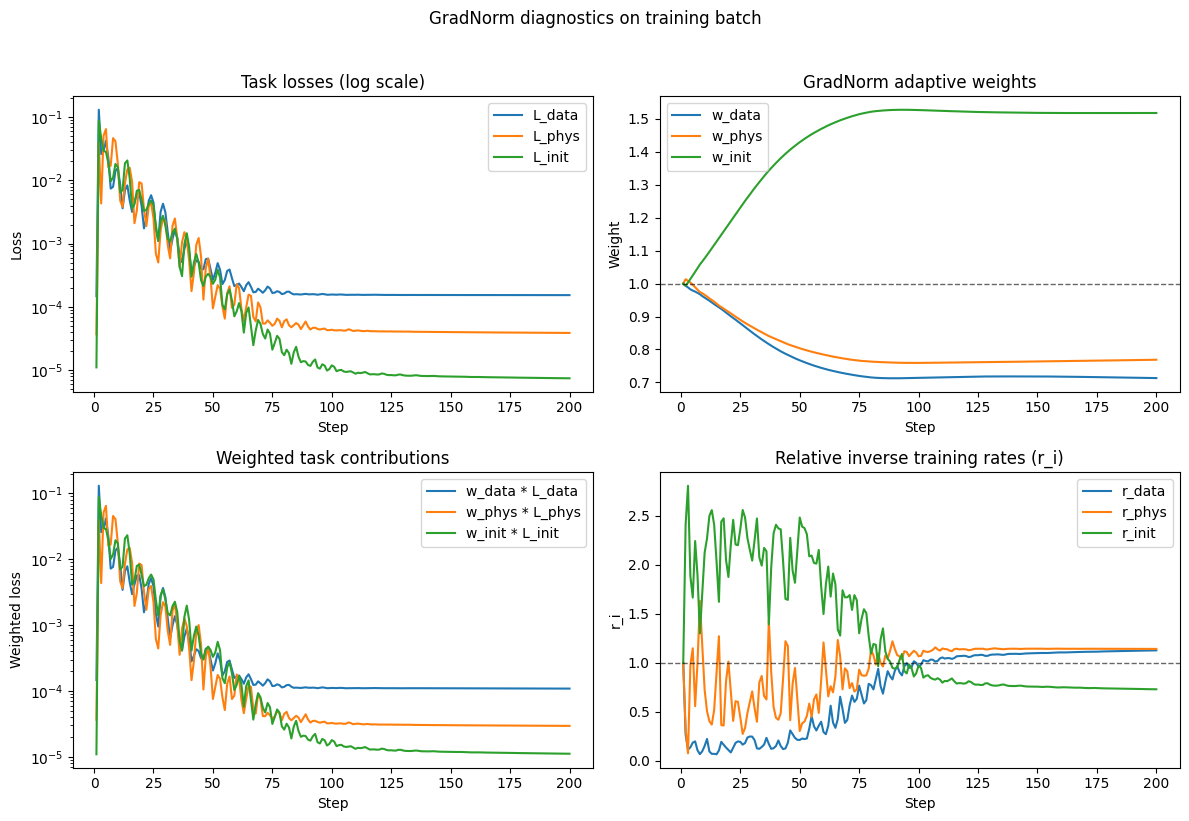

In [23]:
# Visualize the effects of GradNorm loss balancing
import copy
import numpy as np
from matplotlib.pyplot import *

required = [
    'model', 'device', 't_tr', 'x0n_tr', 'un_tr', 'xm_tr', 'x0p_tr',
    'GradNormBalancer', 'gradnorm_step'
 ]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(
        'Missing variables: ' + ', '.join(missing) + '. Run Cells 14 and 30 first.'
    )

# Work on a copy so this diagnostic does not overwrite your trained model
model_vis = copy.deepcopy(model).to(device)
model_vis.train()

balancer = GradNormBalancer(n_tasks=3, alpha=1.5).to(device)
opt_model = torch.optim.Adam(model_vis.parameters(), lr=1e-3)
opt_w = torch.optim.Adam([balancer.logits], lr=1e-2)

n_steps = 200
hist = {
    'L_data': [], 'L_phys': [], 'L_init': [], 'L_total': [], 'L_gn': [],
    'w_data': [], 'w_phys': [], 'w_init': [],
    'g_data': [], 'g_phys': [], 'g_init': [],
    'r_data': [], 'r_phys': [], 'r_init': [],
}

for step in range(n_steps):
    s = gradnorm_step(
        model_vis, balancer, opt_model, opt_w,
        t_tr, x0n_tr, un_tr, xm_tr, x0p_tr
    )
    hist['L_total'].append(s['total'])
    hist['L_data'].append(s['L_data'])
    hist['L_phys'].append(s['L_phys'])
    hist['L_init'].append(s['L_init'])
    hist['L_gn'].append(s['L_gn'])
    hist['w_data'].append(s['weights'][0])
    hist['w_phys'].append(s['weights'][1])
    hist['w_init'].append(s['weights'][2])
    hist['g_data'].append(s['grad_norms'][0])
    hist['g_phys'].append(s['grad_norms'][1])
    hist['g_init'].append(s['grad_norms'][2])
    hist['r_data'].append(s['rel_rates'][0])
    hist['r_phys'].append(s['rel_rates'][1])
    hist['r_init'].append(s['rel_rates'][2])

for k in hist:
    hist[k] = np.array(hist[k])

steps = np.arange(1, n_steps + 1)
wL_data = hist['w_data'] * hist['L_data']
wL_phys = hist['w_phys'] * hist['L_phys']
wL_init = hist['w_init'] * hist['L_init']

fig, axes = subplots(2, 2, figsize=(12, 8))

# (1) Raw task losses
axes[0, 0].plot(steps, hist['L_data'], label='L_data')
axes[0, 0].plot(steps, hist['L_phys'], label='L_phys')
axes[0, 0].plot(steps, hist['L_init'], label='L_init')
axes[0, 0].set_yscale('log')
axes[0, 0].set_title('Task losses (log scale)')
axes[0, 0].set_xlabel('Step')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()

# (2) Adaptive weights
axes[0, 1].plot(steps, hist['w_data'], label='w_data')
axes[0, 1].plot(steps, hist['w_phys'], label='w_phys')
axes[0, 1].plot(steps, hist['w_init'], label='w_init')
axes[0, 1].axhline(1.0, color='k', ls='--', lw=1, alpha=0.6)
axes[0, 1].set_title('GradNorm adaptive weights')
axes[0, 1].set_xlabel('Step')
axes[0, 1].set_ylabel('Weight')
axes[0, 1].legend()

# (3) Weighted task contributions
axes[1, 0].plot(steps, wL_data, label='w_data * L_data')
axes[1, 0].plot(steps, wL_phys, label='w_phys * L_phys')
axes[1, 0].plot(steps, wL_init, label='w_init * L_init')
axes[1, 0].set_yscale('log')
axes[1, 0].set_title('Weighted task contributions')
axes[1, 0].set_xlabel('Step')
axes[1, 0].set_ylabel('Weighted loss')
axes[1, 0].legend()

# (4) Relative inverse training rates r_i
axes[1, 1].plot(steps, hist['r_data'], label='r_data')
axes[1, 1].plot(steps, hist['r_phys'], label='r_phys')
axes[1, 1].plot(steps, hist['r_init'], label='r_init')
axes[1, 1].axhline(1.0, color='k', ls='--', lw=1, alpha=0.6)
axes[1, 1].set_title('Relative inverse training rates (r_i)')
axes[1, 1].set_xlabel('Step')
axes[1, 1].set_ylabel('r_i')
axes[1, 1].legend()

suptitle('GradNorm diagnostics on training batch', y=1.02)
tight_layout()
show()